In [10]:
#importtacion de librerias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [11]:
data = {
    'Color':   ['Rojo', 'Rojo', 'Naranja', 'Naranja', 'Rojo', 'Naranja', 'Rojo', 'Naranja', 'Rojo', 'Naranja'],
    'Tamaño':  ['Grande', 'Pequeño', 'Grande', 'Pequeño', 'Mediano', 'Mediano', 'Grande', 'Pequeño', 'Grande', 'Mediano'],
    'Textura': ['Lisa', 'Lisa', 'Rugosa', 'Rugosa', 'Lisa', 'Rugosa', 'Rugosa', 'Lisa', 'Lisa', 'Lisa'],
    'Origen':  ['Local', 'Importado', 'Local', 'Importado', 'Importado', 'Local', 'Local', 'Importado', 'Local', 'Local'],
    'Brillo':  ['Alto', 'Bajo', 'Bajo', 'Alto', 'Alto', 'Bajo', 'Alto', 'Bajo', 'Bajo', 'Alto'],
    'Fruta':   ['Manzana', 'Manzana', 'Naranja', 'Naranja', 'Manzana', 'Naranja', 'Manzana', 'Naranja', 'Naranja', 'Manzana']
}

df = pd.DataFrame(data)
df

,Color,Tamaño,Textura,Origen,Brillo,Fruta
0,Rojo,Grande,Lisa,Local,Alto,Manzana
1,Rojo,Pequeño,Lisa,Importado,Bajo,Manzana
2,Naranja,Grande,Rugosa,Local,Bajo,Naranja
3,Naranja,Pequeño,Rugosa,Importado,Alto,Naranja
4,Rojo,Mediano,Lisa,Importado,Alto,Manzana
5,Naranja,Mediano,Rugosa,Local,Bajo,Naranja
6,Rojo,Grande,Rugosa,Local,Alto,Manzana
7,Naranja,Pequeño,Lisa,Importado,Bajo,Naranja
8,Rojo,Grande,Lisa,Local,Bajo,Naranja
9,Naranja,Mediano,Lisa,Local,Alto,Manzana


In [12]:
df_endoded = pd.get_dummies(df.drop('Fruta', axis=1))
y = df['Fruta']
X = df_endoded
y = df['Fruta']
df_endoded

,Color_Naranja,Color_Rojo,Tamaño_Grande,Tamaño_Mediano,Tamaño_Pequeño,Textura_Lisa,Textura_Rugosa,Origen_Importado,Origen_Local,Brillo_Alto,Brillo_Bajo
0,False,True,True,False,False,True,False,False,True,True,False
1,False,True,False,False,True,True,False,True,False,False,True
2,True,False,True,False,False,False,True,False,True,False,True
3,True,False,False,False,True,False,True,True,False,True,False
4,False,True,False,True,False,True,False,True,False,True,False
5,True,False,False,True,False,False,True,False,True,False,True
6,False,True,True,False,False,False,True,False,True,True,False
7,True,False,False,False,True,True,False,True,False,False,True
8,False,True,True,False,False,True,False,False,True,False,True
9,True,False,False,True,False,True,False,False,True,True,False


In [13]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=4)
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

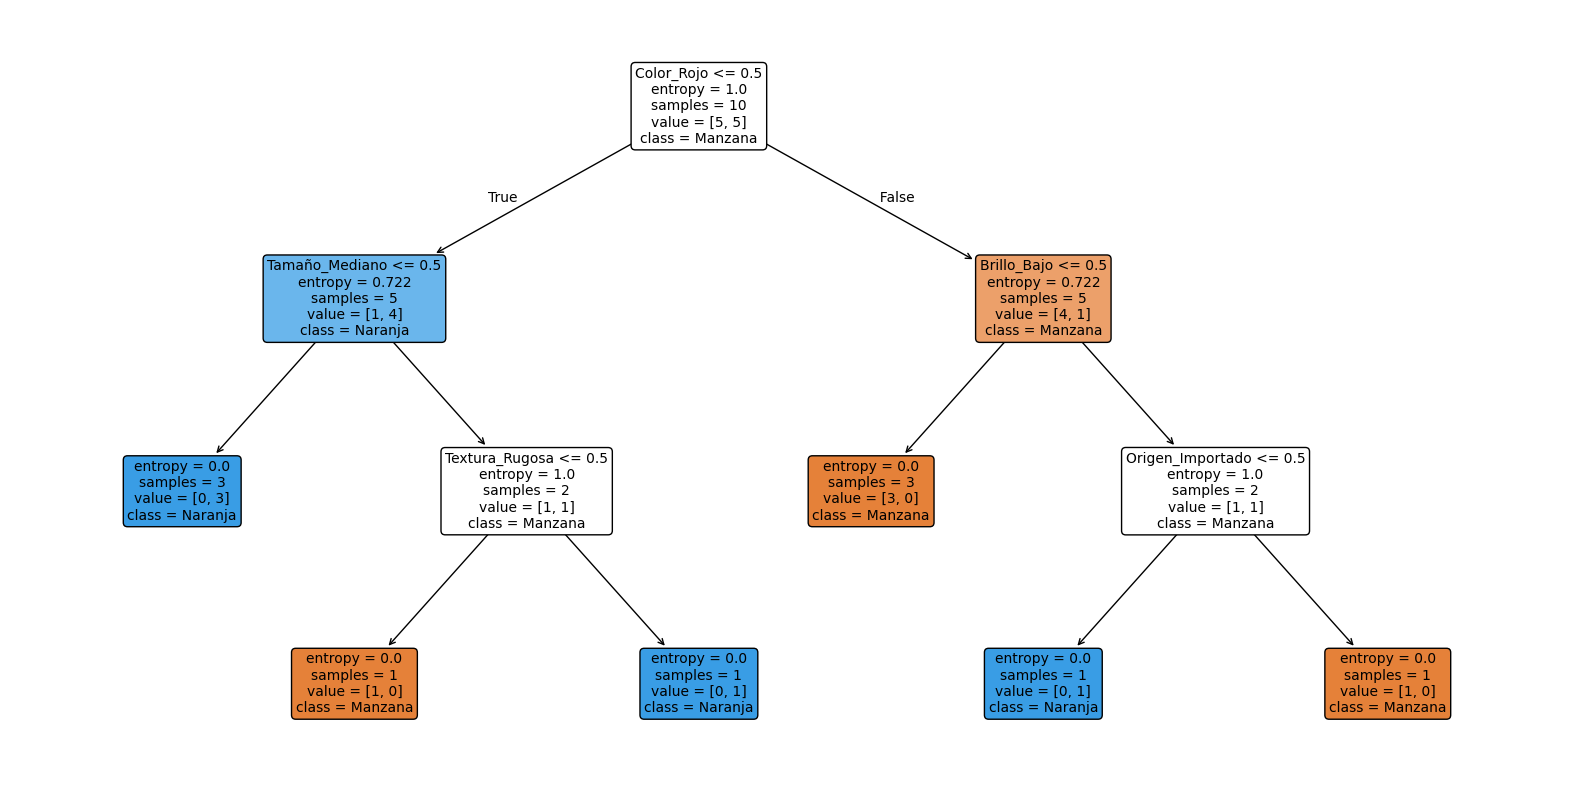

In [14]:
plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=X.columns,
          class_names=model.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

In [15]:
from sklearn.tree import export_text
tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)

|--- Color_Rojo <= 0.50
|   |--- Tamaño_Mediano <= 0.50
|   |   |--- class: Naranja
|   |--- Tamaño_Mediano >  0.50
|   |   |--- Textura_Rugosa <= 0.50
|   |   |   |--- class: Manzana
|   |   |--- Textura_Rugosa >  0.50
|   |   |   |--- class: Naranja
|--- Color_Rojo >  0.50
|   |--- Brillo_Bajo <= 0.50
|   |   |--- class: Manzana
|   |--- Brillo_Bajo >  0.50
|   |   |--- Origen_Importado <= 0.50
|   |   |   |--- class: Naranja
|   |   |--- Origen_Importado >  0.50
|   |   |   |--- class: Manzana



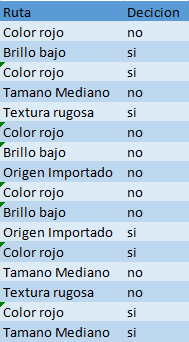